# 2026 World Cup Monte Carlo Simulation

This notebook is a 48-team Monte Carlo simulator.

Features for speed:

1. **Caches all model probabilities before the simulation loop**
2. **Avoids pandas DataFrames inside the simulation loop**
3. **Uses pure Python dictionaries/lists for tournament simulation**
4. **Converts to pandas only at the end**


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pickle
import time
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

DATA_DIR = Path.cwd() / "data"
MODEL_DIR = Path.cwd() / "models"
OUTPUT_DIR = Path.cwd() / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

N_SIMULATIONS = 10000
RANDOM_SEED = 42

print("Current working directory:", Path.cwd())
print("Simulations:", N_SIMULATIONS)


c:\Users\conno\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\conno\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Current working directory: c:\Users\conno\OneDrive\Documents\World Cup Analytics
Simulations: 10000


## 1. Load model and model outputs

In [2]:
MODEL_PATH = MODEL_DIR / "logistic_regression_match_model.pkl"
ELO_PATH = DATA_DIR / "elo_table.csv"
MODEL_READY_PATH = DATA_DIR / "model_ready_matches.csv"

if not MODEL_PATH.exists():
    raise FileNotFoundError(f"Missing model file: {MODEL_PATH}")

if not ELO_PATH.exists():
    raise FileNotFoundError(f"Missing Elo file: {ELO_PATH}")

if not MODEL_READY_PATH.exists():
    raise FileNotFoundError(f"Missing model-ready data: {MODEL_READY_PATH}")

with open(MODEL_PATH, "rb") as f:
    match_model = pickle.load(f)

elo_table = pd.read_csv(ELO_PATH)
model_ready = pd.read_csv(MODEL_READY_PATH)
model_ready["date"] = pd.to_datetime(model_ready["date"], errors="coerce")

print("Model classes:", match_model.classes_)
print("Elo rows:", len(elo_table))
print("Model-ready rows:", len(model_ready))


Model classes: ['away_win' 'draw' 'home_win']
Elo rows: 336
Model-ready rows: 49373


## 2. Define 2026 World Cup groups

In [3]:
team_name_map = {
    "Mexico": "Mexico",
    "South Africa": "South Africa",
    "Korea Republic": "South Korea",
    "Czechia": "Czech Republic",
    "Canada": "Canada",
    "Bosnia and Herzegovina": "Bosnia and Herzegovina",
    "Qatar": "Qatar",
    "Switzerland": "Switzerland",
    "Brazil": "Brazil",
    "Haiti": "Haiti",
    "Morocco": "Morocco",
    "Scotland": "Scotland",
    "United States": "United States",
    "Paraguay": "Paraguay",
    "Australia": "Australia",
    "Türkiye": "Turkey",
    "Germany": "Germany",
    "Curaçao": "Curaçao",
    "Côte d'Ivoire": "Ivory Coast",
    "Ecuador": "Ecuador",
    "Netherlands": "Netherlands",
    "Japan": "Japan",
    "Sweden": "Sweden",
    "Tunisia": "Tunisia",
    "Belgium": "Belgium",
    "Egypt": "Egypt",
    "IR Iran": "Iran",
    "New Zealand": "New Zealand",
    "Spain": "Spain",
    "Cabo Verde": "Cape Verde",
    "Saudi Arabia": "Saudi Arabia",
    "Uruguay": "Uruguay",
    "France": "France",
    "Senegal": "Senegal",
    "Iraq": "Iraq",
    "Norway": "Norway",
    "Argentina": "Argentina",
    "Algeria": "Algeria",
    "Austria": "Austria",
    "Jordan": "Jordan",
    "Portugal": "Portugal",
    "Congo DR": "DR Congo",
    "Uzbekistan": "Uzbekistan",
    "Colombia": "Colombia",
    "England": "England",
    "Croatia": "Croatia",
    "Ghana": "Ghana",
    "Panama": "Panama",
}

groups_official = {
    "Group A": ["Mexico", "South Africa", "Korea Republic", "Czechia"],
    "Group B": ["Canada", "Bosnia and Herzegovina", "Qatar", "Switzerland"],
    "Group C": ["Brazil", "Haiti", "Morocco", "Scotland"],
    "Group D": ["United States", "Paraguay", "Australia", "Türkiye"],
    "Group E": ["Germany", "Curaçao", "Côte d'Ivoire", "Ecuador"],
    "Group F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "Group G": ["Belgium", "Egypt", "IR Iran", "New Zealand"],
    "Group H": ["Spain", "Cabo Verde", "Saudi Arabia", "Uruguay"],
    "Group I": ["France", "Senegal", "Iraq", "Norway"],
    "Group J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "Group K": ["Portugal", "Congo DR", "Uzbekistan", "Colombia"],
    "Group L": ["England", "Croatia", "Ghana", "Panama"],
}

groups_model = {group: [team_name_map[t] for t in teams] for group, teams in groups_official.items()}

model_to_display = {v: k for k, v in team_name_map.items()}
for official, model_name in team_name_map.items():
    model_to_display.setdefault(model_name, official)

all_teams = [team for teams in groups_model.values() for team in teams]

print("Teams:", len(all_teams))
print("Unique teams:", len(set(all_teams)))


Teams: 48
Unique teams: 48


## 3. Build team-strength lookups

In [4]:
elo_lookup = dict(zip(elo_table["team"], elo_table["elo"]))

missing_from_elo = [team for team in all_teams if team not in elo_lookup]
if missing_from_elo:
    print("WARNING: These teams were not found in the Elo table and will default to 1500:")
    for team in missing_from_elo:
        print("-", team)
else:
    print("All teams found in Elo table.")

team_recent = {}

for team in sorted(set(model_ready["home_team"]).union(set(model_ready["away_team"]))):
    team_matches = model_ready[
        (model_ready["home_team"] == team) | (model_ready["away_team"] == team)
    ].sort_values("date")

    if len(team_matches) == 0:
        continue

    last = team_matches.iloc[-1]

    if last["home_team"] == team:
        team_recent[team] = {
            "form_pts_5": last.get("home_form_pts_5", np.nan),
            "gf_avg_5": last.get("home_gf_avg_5", np.nan),
            "ga_avg_5": last.get("home_ga_avg_5", np.nan),
            "gd_avg_5": last.get("home_gd_avg_5", np.nan),
            "matches_played_pre": last.get("home_matches_played_pre", np.nan),
        }
    else:
        team_recent[team] = {
            "form_pts_5": last.get("away_form_pts_5", np.nan),
            "gf_avg_5": last.get("away_gf_avg_5", np.nan),
            "ga_avg_5": last.get("away_ga_avg_5", np.nan),
            "gd_avg_5": last.get("away_gd_avg_5", np.nan),
            "matches_played_pre": last.get("away_matches_played_pre", np.nan),
        }

def get_team_elo(team):
    return float(elo_lookup.get(team, 1500))

def get_team_recent(team):
    defaults = {
        "form_pts_5": 1.0,
        "gf_avg_5": 1.25,
        "ga_avg_5": 1.25,
        "gd_avg_5": 0.0,
        "matches_played_pre": 0,
    }

    values = team_recent.get(team, defaults).copy()

    for key, default_value in defaults.items():
        if pd.isna(values.get(key, np.nan)):
            values[key] = default_value

    return values


All teams found in Elo table.


## 4. Cache all matchup probabilities

Instead of calling `match_model.predict_proba()` inside every simulated match, this section precomputes every possible ordered matchup once.


In [5]:
def build_match_features(team_a, team_b):
    elo_a = get_team_elo(team_a)
    elo_b = get_team_elo(team_b)

    recent_a = get_team_recent(team_a)
    recent_b = get_team_recent(team_b)

    return pd.DataFrame([{
        "home_elo_pre": elo_a,
        "away_elo_pre": elo_b,
        "elo_diff": elo_a - elo_b,
        "elo_abs_diff": abs(elo_a - elo_b),
        "home_form_pts_5": recent_a["form_pts_5"],
        "away_form_pts_5": recent_b["form_pts_5"],
        "form_pts_diff_5": recent_a["form_pts_5"] - recent_b["form_pts_5"],
        "home_gf_avg_5": recent_a["gf_avg_5"],
        "away_gf_avg_5": recent_b["gf_avg_5"],
        "gf_avg_diff_5": recent_a["gf_avg_5"] - recent_b["gf_avg_5"],
        "home_ga_avg_5": recent_a["ga_avg_5"],
        "away_ga_avg_5": recent_b["ga_avg_5"],
        "ga_avg_diff_5": recent_a["ga_avg_5"] - recent_b["ga_avg_5"],
        "home_gd_avg_5": recent_a["gd_avg_5"],
        "away_gd_avg_5": recent_b["gd_avg_5"],
        "gd_avg_diff_5": recent_a["gd_avg_5"] - recent_b["gd_avg_5"],
        "home_matches_played_pre": recent_a["matches_played_pre"],
        "away_matches_played_pre": recent_b["matches_played_pre"],
        "matches_played_diff_pre": recent_a["matches_played_pre"] - recent_b["matches_played_pre"],
        "neutral": 1,
        "is_world_cup": 1,
        "is_qualifier": 0,
        "is_friendly": 0,
    }])

start = time.time()
probability_cache = {}

for team_a in all_teams:
    for team_b in all_teams:
        if team_a == team_b:
            continue

        X = build_match_features(team_a, team_b)
        probs = match_model.predict_proba(X)[0]
        prob_dict = dict(zip(match_model.classes_, probs))

        probability_cache[(team_a, team_b)] = (
            float(prob_dict.get("home_win", 0)),
            float(prob_dict.get("draw", 0)),
            float(prob_dict.get("away_win", 0)),
        )

elapsed = time.time() - start
print(f"Cached {len(probability_cache):,} ordered matchups in {elapsed:.2f} seconds.")


Cached 2,256 ordered matchups in 11.35 seconds.


## 5. Fast simulation functions

In [6]:
def simulate_group_match_fast(team_a, team_b, rng):
    p_home, p_draw, p_away = probability_cache[(team_a, team_b)]
    total = p_home + p_draw + p_away
    p_home = p_home / total
    p_draw = p_draw / total

    r = rng.random()

    if r < p_home:
        margin = int(rng.choice([1, 2, 3], p=[0.70, 0.25, 0.05]))
        loser_goals = int(rng.choice([0, 1, 2], p=[0.45, 0.40, 0.15]))
        winner_goals = loser_goals + margin
        return {
            team_a: (3, winner_goals, loser_goals, 1, 0, 0),
            team_b: (0, loser_goals, winner_goals, 0, 0, 1),
        }

    if r < p_home + p_draw:
        draw_goals = int(rng.choice([0, 1, 2, 3], p=[0.25, 0.45, 0.25, 0.05]))
        return {
            team_a: (1, draw_goals, draw_goals, 0, 1, 0),
            team_b: (1, draw_goals, draw_goals, 0, 1, 0),
        }

    margin = int(rng.choice([1, 2, 3], p=[0.70, 0.25, 0.05]))
    loser_goals = int(rng.choice([0, 1, 2], p=[0.45, 0.40, 0.15]))
    winner_goals = loser_goals + margin
    return {
        team_a: (0, loser_goals, winner_goals, 0, 0, 1),
        team_b: (3, winner_goals, loser_goals, 1, 0, 0),
    }


def simulate_knockout_match_fast(team_a, team_b, rng):
    p_a, _, p_b = probability_cache[(team_a, team_b)]
    non_draw = p_a + p_b
    p_a_adjusted = 0.5 if non_draw <= 0 else p_a / non_draw
    return team_a if rng.random() < p_a_adjusted else team_b


def simulate_group_fast(group_name, teams, rng):
    table = {}

    for team in teams:
        table[team] = {
            "group": group_name,
            "team": team,
            "points": 0,
            "gf": 0,
            "ga": 0,
            "gd": 0,
            "wins": 0,
            "draws": 0,
            "losses": 0,
            "random_tiebreaker": rng.random(),
        }

    for i in range(len(teams)):
        for j in range(i + 1, len(teams)):
            team_a = teams[i]
            team_b = teams[j]
            match_result = simulate_group_match_fast(team_a, team_b, rng)

            for team, stats in match_result.items():
                points, gf, ga, wins, draws, losses = stats
                table[team]["points"] += points
                table[team]["gf"] += gf
                table[team]["ga"] += ga
                table[team]["wins"] += wins
                table[team]["draws"] += draws
                table[team]["losses"] += losses

    for team in teams:
        table[team]["gd"] = table[team]["gf"] - table[team]["ga"]

    standings = sorted(
        table.values(),
        key=lambda x: (x["points"], x["gd"], x["gf"], x["wins"], x["random_tiebreaker"]),
        reverse=True,
    )

    for rank, row in enumerate(standings, start=1):
        row["group_rank"] = rank

    return standings


def get_qualifiers_fast(all_group_standings):
    top_two = []
    third_place = []

    for row in all_group_standings:
        if row["group_rank"] in [1, 2]:
            top_two.append(row)
        elif row["group_rank"] == 3:
            third_place.append(row)

    best_thirds = sorted(
        third_place,
        key=lambda x: (x["points"], x["gd"], x["gf"], x["wins"], x["random_tiebreaker"]),
        reverse=True,
    )[:8]

    return top_two + best_thirds


def seed_qualifiers_fast(qualifiers):
    winners = [q for q in qualifiers if q["group_rank"] == 1]
    runners = [q for q in qualifiers if q["group_rank"] == 2]
    thirds = [q for q in qualifiers if q["group_rank"] == 3]

    sort_key = lambda x: (x["points"], x["gd"], x["gf"], x["wins"], x["random_tiebreaker"])

    seeded_rows = (
        sorted(winners, key=sort_key, reverse=True)
        + sorted(runners, key=sort_key, reverse=True)
        + sorted(thirds, key=sort_key, reverse=True)
    )

    return {seed: row["team"] for seed, row in enumerate(seeded_rows, start=1)}


def build_r32_matches_fast(seed_lookup):
    bracket_seed_pairs = [
        (1, 32), (16, 17), (8, 25), (9, 24),
        (4, 29), (13, 20), (5, 28), (12, 21),
        (2, 31), (15, 18), (7, 26), (10, 23),
        (3, 30), (14, 19), (6, 27), (11, 22),
    ]
    return [(seed_lookup[a], seed_lookup[b]) for a, b in bracket_seed_pairs]


def pair_adjacent(teams):
    return [(teams[i], teams[i + 1]) for i in range(0, len(teams), 2)]


def simulate_knockout_round_fast(matches, rng):
    return [simulate_knockout_match_fast(a, b, rng) for a, b in matches]


def simulate_2026_world_cup_fast(groups_model, rng):
    group_standings = []

    for group_name, teams in groups_model.items():
        group_standings.extend(simulate_group_fast(group_name, teams, rng))

    qualifiers = get_qualifiers_fast(group_standings)
    seed_lookup = seed_qualifiers_fast(qualifiers)

    r32_matches = build_r32_matches_fast(seed_lookup)
    r16_teams = simulate_knockout_round_fast(r32_matches, rng)
    qf_teams = simulate_knockout_round_fast(pair_adjacent(r16_teams), rng)
    sf_teams = simulate_knockout_round_fast(pair_adjacent(qf_teams), rng)
    final_teams = simulate_knockout_round_fast(pair_adjacent(sf_teams), rng)
    champion = simulate_knockout_match_fast(final_teams[0], final_teams[1], rng)

    return {
        "advance_from_group": {row["team"] for row in qualifiers},
        "reach_round_of_16": set(r16_teams),
        "reach_quarterfinal": set(qf_teams),
        "reach_semifinal": set(sf_teams),
        "reach_final": set(final_teams),
        "win_title": {champion},
    }


## 6. Run optimized Monte Carlo simulation

In [7]:
rng = np.random.default_rng(RANDOM_SEED)

stage_names = [
    "advance_from_group",
    "reach_round_of_16",
    "reach_quarterfinal",
    "reach_semifinal",
    "reach_final",
    "win_title",
]

stage_counts = {team: {stage: 0 for stage in stage_names} for team in all_teams}

start = time.time()

for sim in range(N_SIMULATIONS):
    stages = simulate_2026_world_cup_fast(groups_model, rng)

    for stage_name, teams in stages.items():
        for team in teams:
            stage_counts[team][stage_name] += 1

    if (sim + 1) % 1000 == 0:
        elapsed = time.time() - start
        print(f"{sim + 1:,} simulations complete | {elapsed:.1f} seconds elapsed")

elapsed = time.time() - start
print(f"Finished {N_SIMULATIONS:,} simulations in {elapsed:.1f} seconds.")


1,000 simulations complete | 4.2 seconds elapsed
2,000 simulations complete | 9.5 seconds elapsed
3,000 simulations complete | 15.2 seconds elapsed
4,000 simulations complete | 20.5 seconds elapsed
5,000 simulations complete | 26.1 seconds elapsed
6,000 simulations complete | 31.3 seconds elapsed
7,000 simulations complete | 37.2 seconds elapsed
8,000 simulations complete | 43.6 seconds elapsed
9,000 simulations complete | 48.9 seconds elapsed
10,000 simulations complete | 53.7 seconds elapsed
Finished 10,000 simulations in 53.7 seconds.


## 7. Convert results to pandas

In [8]:
results = pd.DataFrame.from_dict(stage_counts, orient="index").reset_index()
results = results.rename(columns={"index": "model_team"})
results["team"] = results["model_team"].map(lambda x: model_to_display.get(x, x))

for stage in stage_names:
    results[stage + "_pct"] = results[stage] / N_SIMULATIONS

team_to_group = {}
for group_name, teams in groups_model.items():
    for team in teams:
        team_to_group[team] = group_name

results["group"] = results["model_team"].map(team_to_group)
results = results.sort_values("win_title_pct", ascending=False).reset_index(drop=True)

display_cols = [
    "team",
    "group",
    "advance_from_group_pct",
    "reach_round_of_16_pct",
    "reach_quarterfinal_pct",
    "reach_semifinal_pct",
    "reach_final_pct",
    "win_title_pct",
]

results[display_cols].head(48)


,team,group,advance_from_group_pct,reach_round_of_16_pct,reach_quarterfinal_pct,reach_semifinal_pct,reach_final_pct,win_title_pct
0,Argentina,Group J,0.9675,0.8098,0.6262,0.4634,0.3204,0.2103
1,Spain,Group H,0.9896,0.8245,0.6223,0.4513,0.3134,0.2065
2,England,Group L,0.9802,0.7760,0.5437,0.3526,0.2189,0.1234
3,France,Group I,0.9295,0.7159,0.4924,0.3141,0.1861,0.1033
4,Brazil,Group C,0.9152,0.6397,0.3987,0.2225,0.1142,0.0523
5,Germany,Group E,0.9564,0.6677,0.4110,0.2294,0.1153,0.0505
6,Portugal,Group K,0.9153,0.6302,0.3679,0.1926,0.0921,0.0418
7,Netherlands,Group F,0.8865,0.5924,0.3488,0.1861,0.0860,0.0377
8,Mexico,Group A,0.9180,0.5821,0.3117,0.1390,0.0581,0.0220
9,Japan,Group F,0.8580,0.5284,0.2807,0.1314,0.0562,0.0214


## 8. Visualize title odds

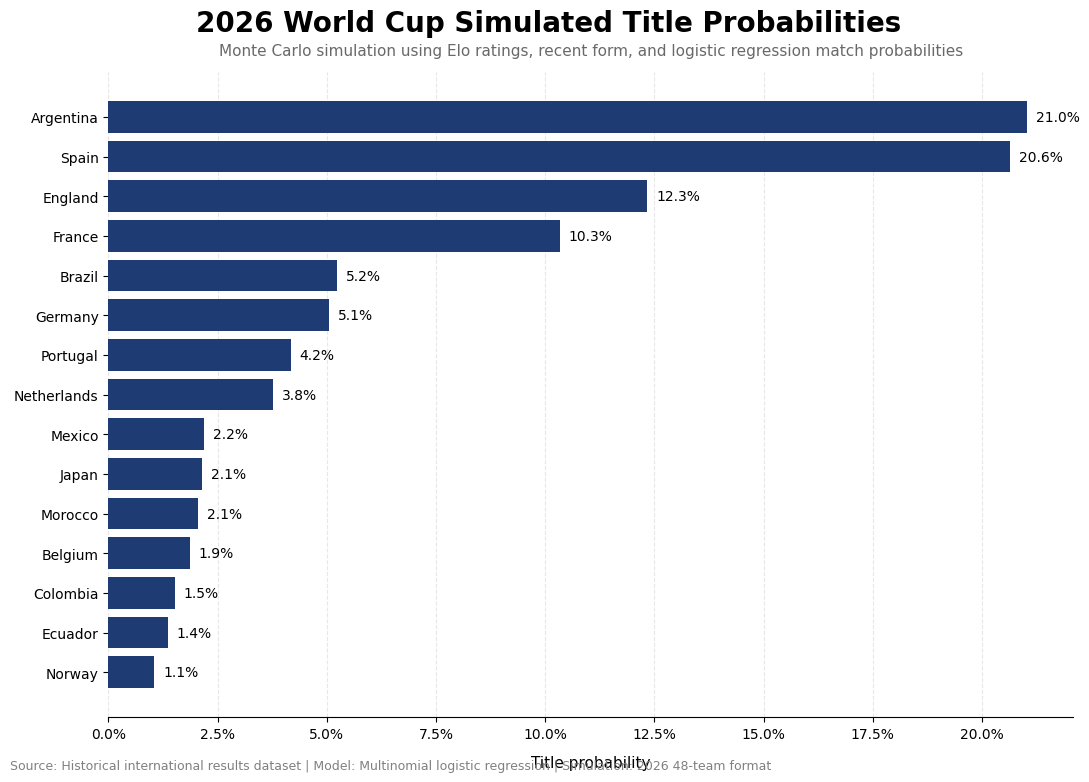

In [42]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Top 15 teams by title probability
plot_df = (
    results
    .sort_values("win_title_pct", ascending=False)
    .head(15)
    .sort_values("win_title_pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    plot_df["team"],
    plot_df["win_title_pct"],
    color="#1f3b73"
)

# Add percentage labels
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1%}",
        va="center",
        fontsize=10
    )

# Titles
fig.suptitle(
    "2026 World Cup Simulated Title Probabilities",
    fontsize=20,
    fontweight="bold",
    y=0.97
)

ax.set_title(
    "Monte Carlo simulation using Elo ratings, recent form, and logistic regression match probabilities",
    fontsize=11,
    color="dimgray",
    pad=12
)

# Axis formatting
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_xlabel(
    "Title probability",
    fontsize=11,
    labelpad=10
)
ax.set_ylabel("")

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.set_axisbelow(True)

# Footer
fig.text(
    0.01,
    0.02,
    "Source: Historical international results dataset | Model: Multinomial logistic regression | Simulation: 2026 48-team format",
    fontsize=9,
    color="gray",
    ha="left"
)

plt.tight_layout()

# Save high-res image for LinkedIn
plt.savefig(
    "world_cup_2026_title_odds_linkedin.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 9. Group advancement view

In [10]:
group_view = (
    results[display_cols]
    .sort_values(["group", "advance_from_group_pct"], ascending=[True, False])
    .reset_index(drop=True)
)

group_view


,team,group,advance_from_group_pct,reach_round_of_16_pct,reach_quarterfinal_pct,reach_semifinal_pct,reach_final_pct,win_title_pct
0,Mexico,Group A,0.9180,0.5821,0.3117,0.1390,0.0581,0.0220
1,Korea Republic,Group A,0.8628,0.4362,0.1825,0.0681,0.0217,0.0051
2,Czechia,Group A,0.5712,0.1456,0.0327,0.0062,0.0003,0.0001
3,South Africa,Group A,0.3312,0.0505,0.0086,0.0008,0.0000,0.0000
4,Switzerland,Group B,0.9403,0.5358,0.2445,0.0989,0.0337,0.0096
5,Canada,Group B,0.8731,0.3815,0.1282,0.0381,0.0089,0.0014
6,Bosnia and Herzegovina,Group B,0.4178,0.0548,0.0062,0.0003,0.0000,0.0000
7,Qatar,Group B,0.4139,0.0576,0.0065,0.0006,0.0000,0.0000
8,Brazil,Group C,0.9152,0.6397,0.3987,0.2225,0.1142,0.0523
9,Morocco,Group C,0.8664,0.5246,0.2771,0.1326,0.0551,0.0205


Identify potential group advancement sleepers

In [34]:
# Better sleeper identification:
# teams that are likely to escape the group,
# but are not major title contenders

sleeper_df = results.copy()

sleeper_df["title_rank"] = sleeper_df["win_title_pct"].rank(
    ascending=False,
    method="min"
)

# Exclude obvious favorites
sleeper_candidates = sleeper_df[
    (sleeper_df["title_rank"] > 12) &
    (sleeper_df["advance_from_group_pct"] >= 0.35)
].copy()

# Advancement efficiency:
# high group advancement odds despite low title odds
sleeper_candidates["sleeper_score"] = (
    sleeper_candidates["advance_from_group_pct"]
    / (sleeper_candidates["win_title_pct"] + 0.01)
)

sleepers = (
    sleeper_candidates
    .sort_values("sleeper_score", ascending=False)
    .head(7)
    .reset_index(drop=True)
)

sleepers[
    [
        "team",
        "group",
        "advance_from_group_pct",
        "reach_round_of_16_pct",
        "reach_quarterfinal_pct",
        "win_title_pct",
        "title_rank",
        "sleeper_score"
    ]
]

,team,group,advance_from_group_pct,reach_round_of_16_pct,reach_quarterfinal_pct,win_title_pct,title_rank,sleeper_score
0,Canada,Group B,0.8731,0.3815,0.1282,0.0014,26.0,76.587719
1,Croatia,Group L,0.8314,0.3754,0.1359,0.0024,23.0,67.048387
2,Côte d'Ivoire,Group E,0.6480,0.1812,0.0483,0.0001,32.0,64.158416
3,Egypt,Group G,0.6703,0.2480,0.0753,0.0006,30.0,63.235849
4,Scotland,Group C,0.6690,0.2566,0.0855,0.0009,29.0,61.376147
5,Paraguay,Group D,0.6766,0.2965,0.1119,0.0017,25.0,57.829060
6,Korea Republic,Group A,0.8628,0.4362,0.1825,0.0051,19.0,57.139073


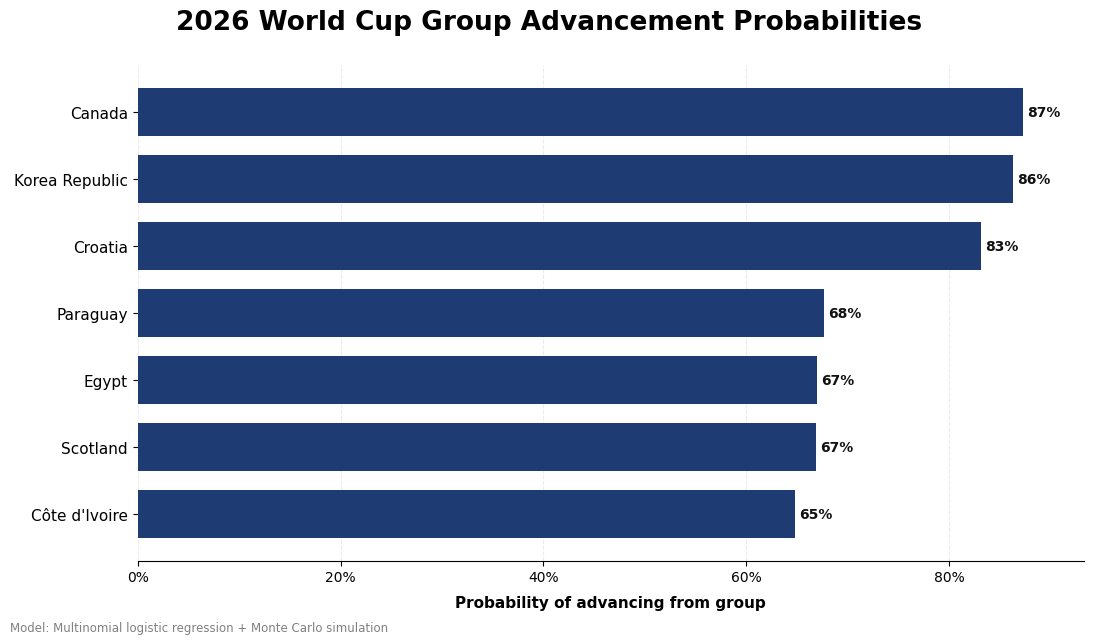

In [54]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# Selected sleeper/team list ranked by advancement probability
plot_df = (
    sleepers
    .sort_values("advance_from_group_pct", ascending=False)
    .head(7)
    .sort_values("advance_from_group_pct", ascending=True)
)

fig, ax = plt.subplots(figsize=(11, 7))

# Bars
bars = ax.barh(
    plot_df["team"],
    plot_df["advance_from_group_pct"],
    color="#1f3b73",
    height=0.72
)

# Percentage labels
for bar in bars:
    width = bar.get_width()

    ax.text(
        width + 0.004,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.0%}",
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#111111"
    )

# Main title
fig.suptitle(
    "2026 World Cup Group Advancement Probabilities",
    fontsize=19,
    fontweight="bold",
    y=0.9
)

# X-axis formatting
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0))

ax.set_xlim(
    0,
    min(1.0, plot_df["advance_from_group_pct"].max() + 0.06)
)

ax.set_xlabel(
    "Probability of advancing from group",
    fontsize=11,
    labelpad=8,
    fontweight="bold"
)

ax.set_ylabel("")

# Clean styling
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.grid(axis="x", linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Tick styling
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", labelsize=10)

# Footer
fig.text(
    0.01,
    0.012,
    "Model: Multinomial logistic regression + Monte Carlo simulation",
    fontsize=8.5,
    color="gray",
    ha="left"
)

# Tight layout with reduced whitespace
plt.tight_layout(rect=[0, 0.02, 1, 0.90])

# Save image
plt.savefig(
    "world_cup_2026_selected_group_advancement.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Save outputs

In [11]:
results_path = OUTPUT_DIR / "world_cup_2026_optimized_monte_carlo_results.csv"
group_view_path = OUTPUT_DIR / "world_cup_2026_optimized_group_advancement_results.csv"

results.to_csv(results_path, index=False)
group_view.to_csv(group_view_path, index=False)

print("Saved:")
print(results_path)
print(group_view_path)


Saved:
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\world_cup_2026_optimized_monte_carlo_results.csv
c:\Users\conno\OneDrive\Documents\World Cup Analytics\outputs\world_cup_2026_optimized_group_advancement_results.csv
